# ForecastLab

---

## Power Consumption Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-002 |
| **Eksperimen** | EXP-002 |
| **Nama Eksperimen** | Exploratory Data Analysis |
| **Dataset** | powerconsumption.csv |
| **Author** | GAKUSEI Najib |

---

## 1. Tujuan Eksperimen

Menemukan pola, tren, distribusi, hubungan antar feature, serta insight awal untuk feature engineering dan modeling.

---
## 2. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

INPUT_PATH = '../data/powerconsumption.csv'
df = pd.read_csv(INPUT_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Date'] = df['Datetime'].dt.date
df['Hour'] = df['Datetime'].dt.hour
df['Month'] = df['Datetime'].dt.month
df['Weekday'] = df['Datetime'].dt.weekday
print(f'Dataset: {df.shape}')

Dataset: (52416, 13)


---
## 3. Distribusi Konsumsi Daya per Zona

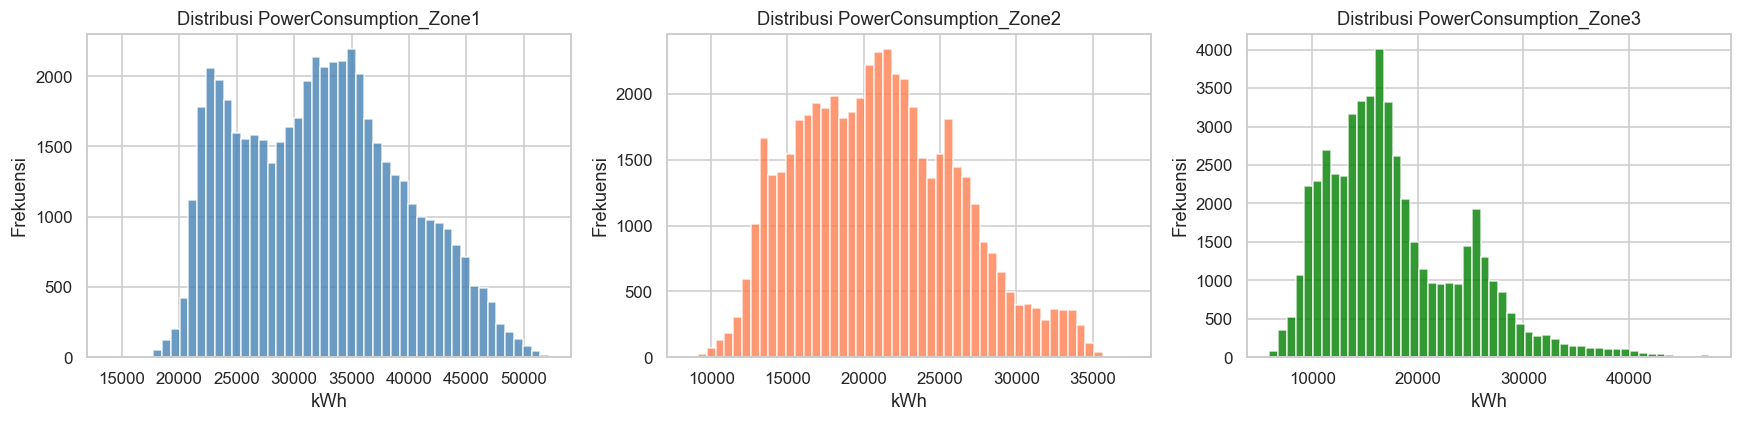

In [2]:
target_cols = ['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['steelblue', 'coral', 'green']
for i, (col, color) in enumerate(zip(target_cols, colors)):
    axes[i].hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('kWh')
    axes[i].set_ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('../data/eda_01_distribusi_power.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 4. Tren Konsumsi Daya Harian

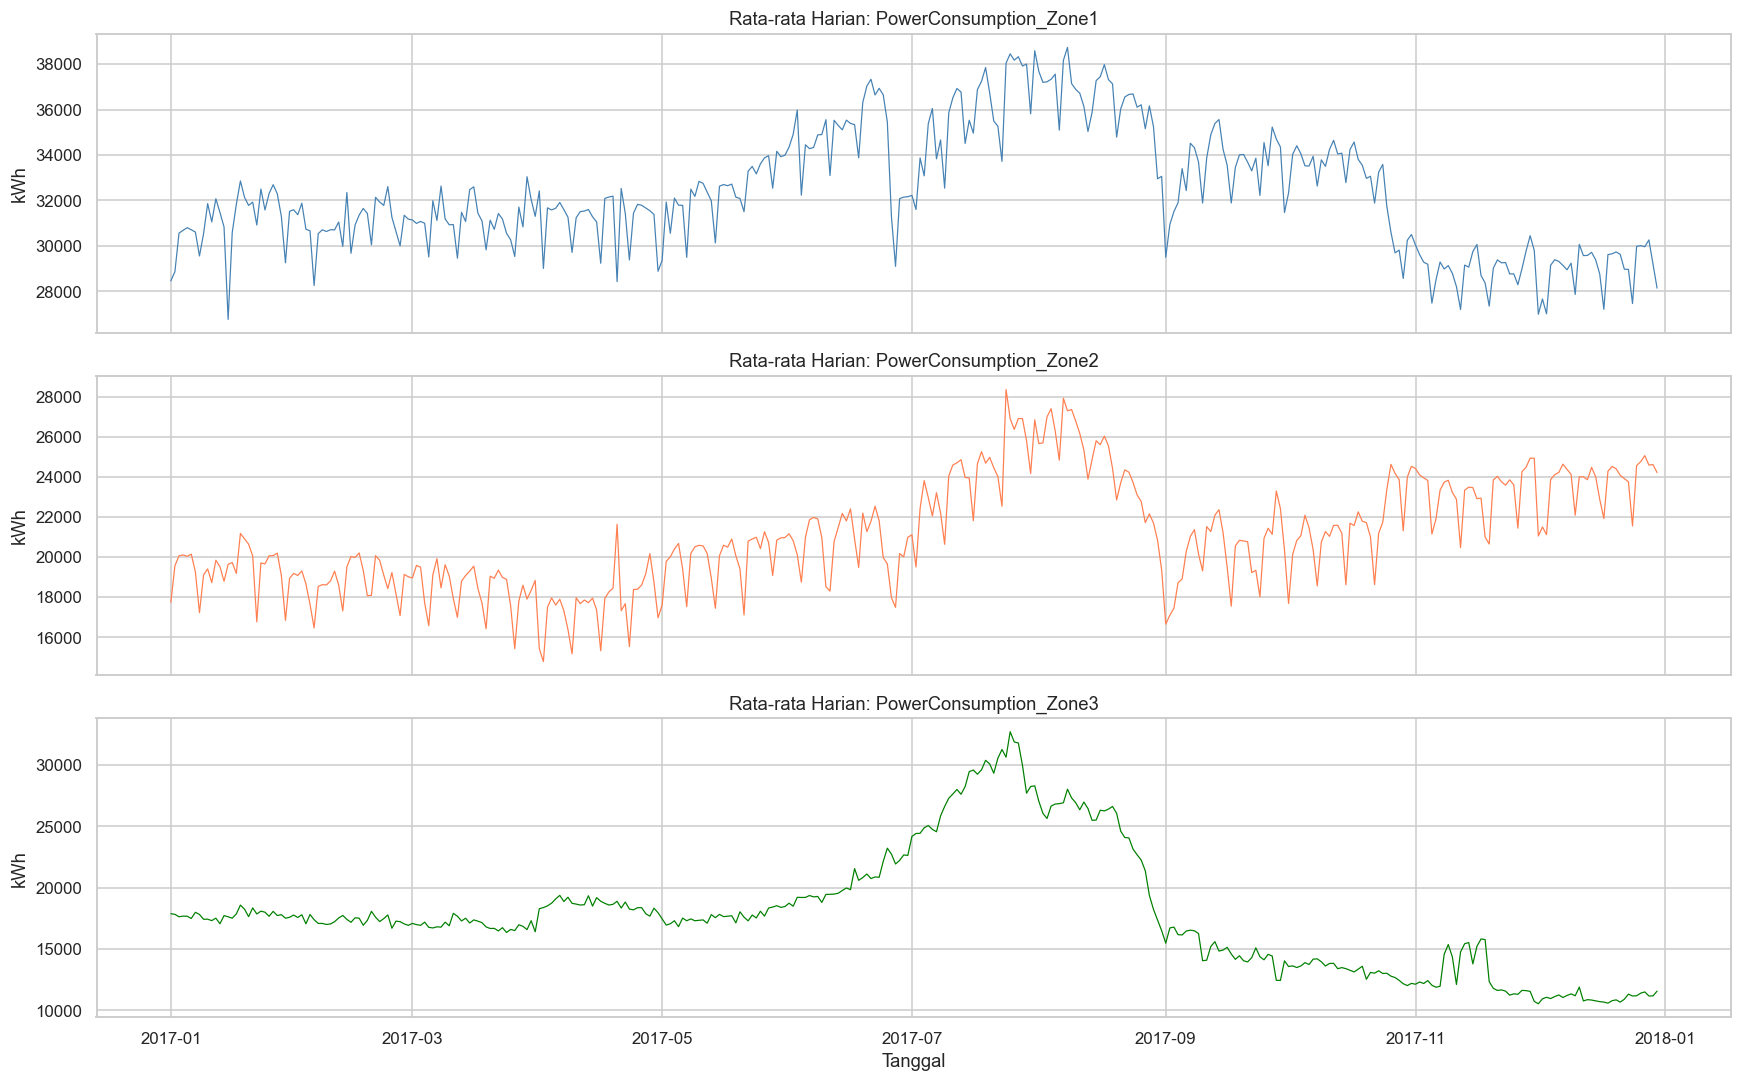

In [3]:
daily = df.groupby('Date')[target_cols].mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for i, (col, color) in enumerate(zip(target_cols, colors)):
    axes[i].plot(daily.index, daily[col], color=color, linewidth=0.8)
    axes[i].set_title(f'Rata-rata Harian: {col}')
    axes[i].set_ylabel('kWh')
plt.xlabel('Tanggal')
plt.tight_layout()
plt.savefig('../data/eda_02_tren_harian.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 5. Pola Konsumsi Daya per Jam

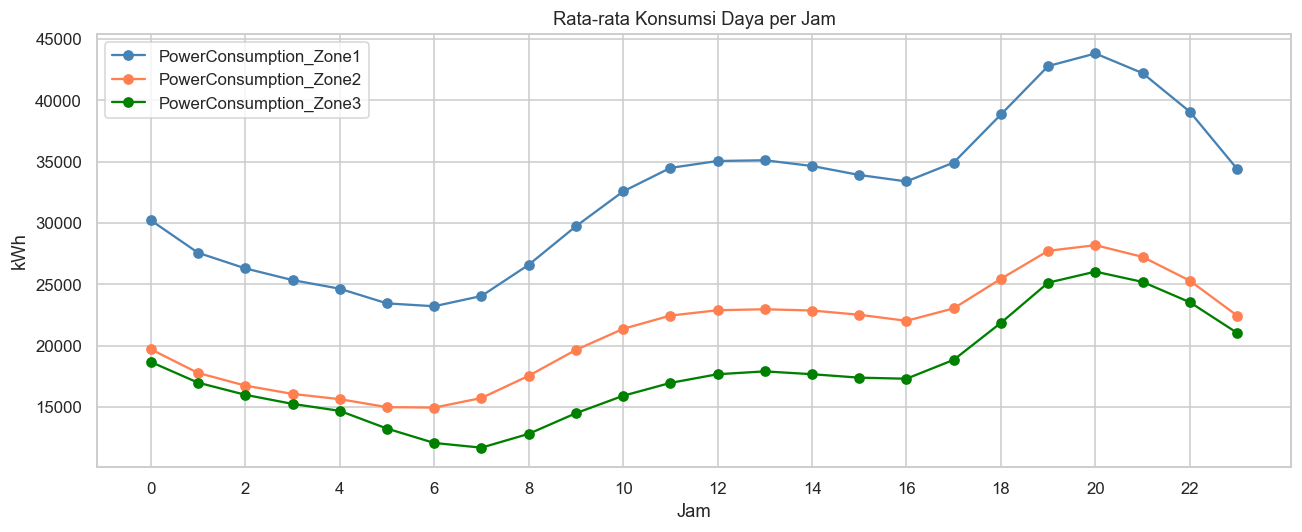

In [4]:
hourly = df.groupby('Hour')[target_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(target_cols, colors):
    ax.plot(hourly.index, hourly[col], 'o-', label=col, color=color)
ax.set_title('Rata-rata Konsumsi Daya per Jam')
ax.set_xlabel('Jam')
ax.set_ylabel('kWh')
ax.legend()
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig('../data/eda_03_pola_per_jam.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 6. Pola Weekday vs Weekend

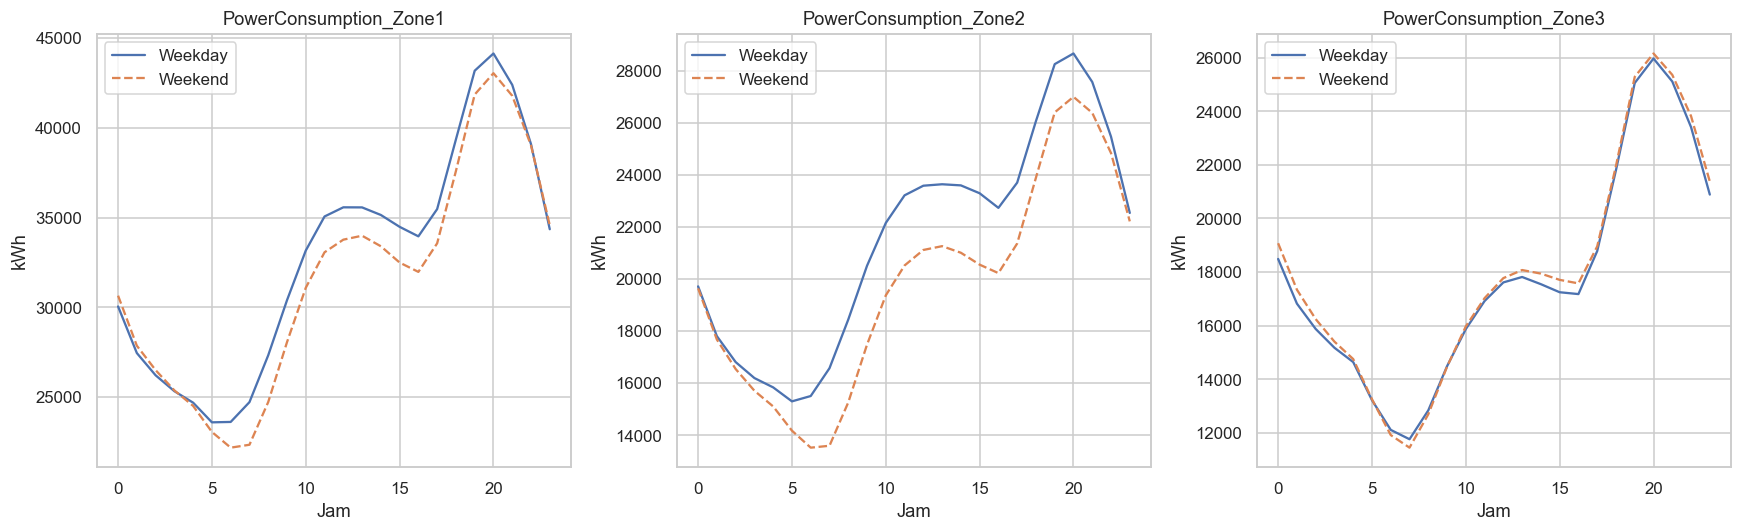

In [5]:
df['DayType'] = df['Weekday'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
daytype = df.groupby(['Hour', 'DayType'])[target_cols].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(target_cols):
    for dt, style in zip(['Weekday', 'Weekend'], ['-', '--']):
        subset = daytype[daytype['DayType'] == dt]
        axes[i].plot(subset['Hour'], subset[col], style, label=dt)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Jam')
    axes[i].set_ylabel('kWh')
    axes[i].legend()
plt.tight_layout()
plt.savefig('../data/eda_04_weekday_weekend.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 7. Hubungan Suhu dengan Konsumsi Daya

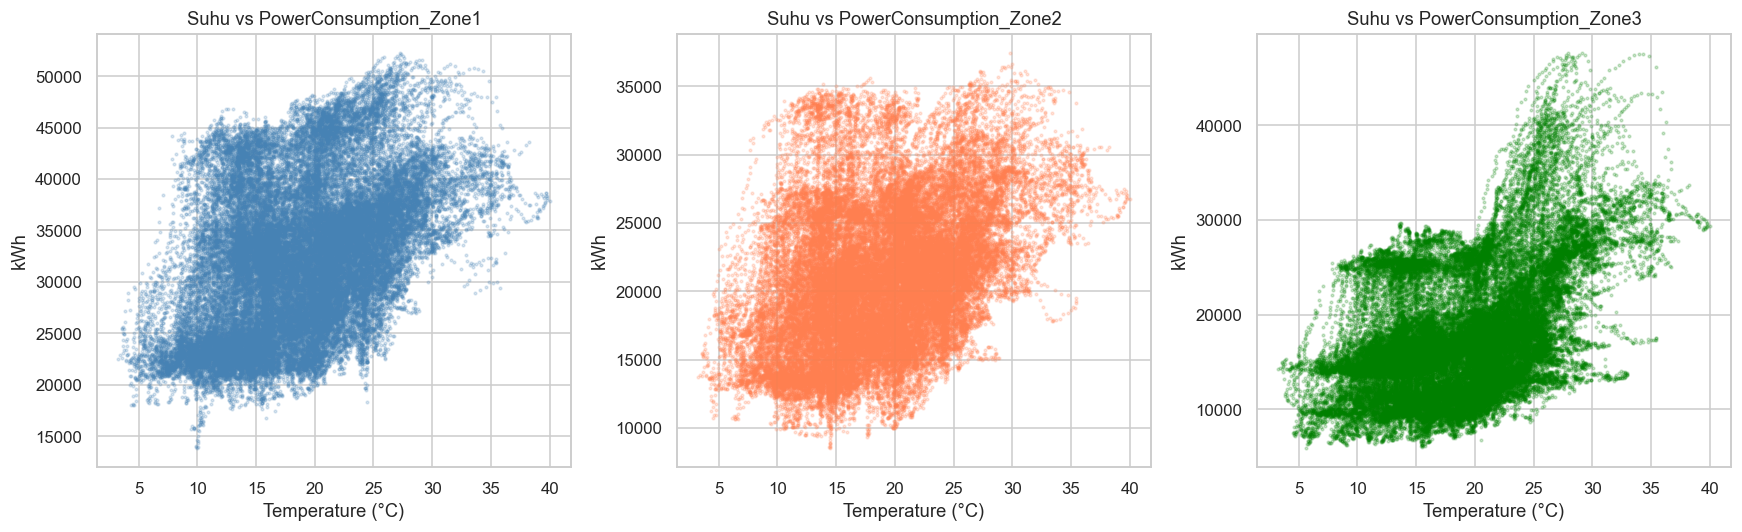

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (col, color) in enumerate(zip(target_cols, colors)):
    axes[i].scatter(df['Temperature'], df[col], alpha=0.2, s=3, color=color)
    axes[i].set_title(f'Suhu vs {col}')
    axes[i].set_xlabel('Temperature (°C)')
    axes[i].set_ylabel('kWh')
plt.tight_layout()
plt.savefig('../data/eda_05_suhu_vs_power.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 8. Correlation Matrix

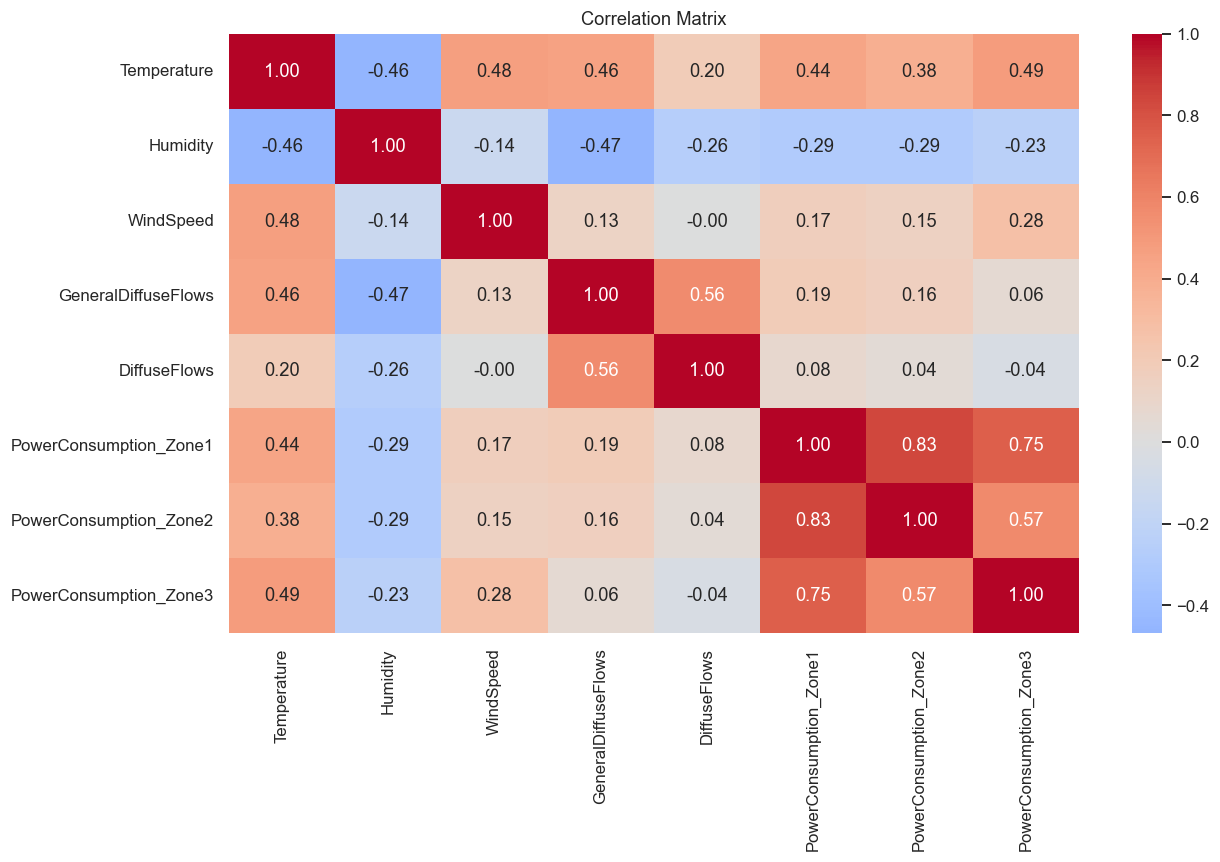

In [7]:
corr_cols = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows'] + target_cols
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/eda_06_correlation_matrix.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 9. Boxplot Konsumsi Daya per Bulan

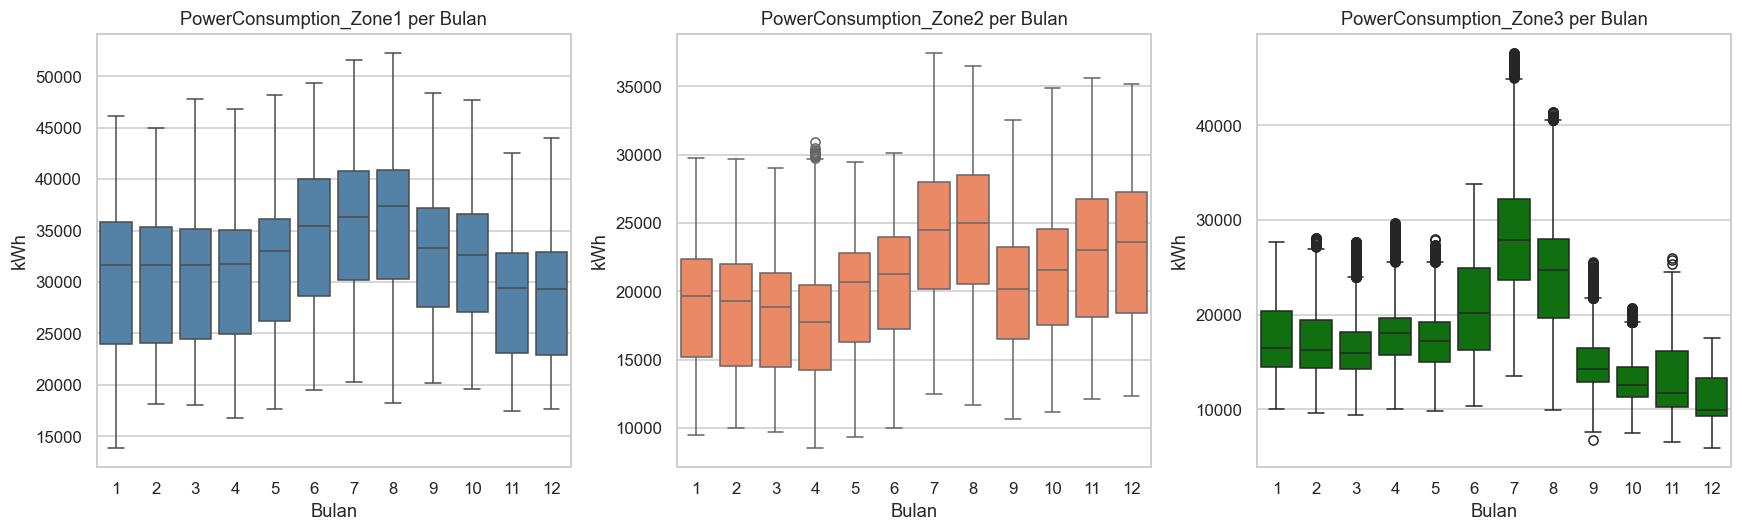

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (col, color) in enumerate(zip(target_cols, colors)):
    sns.boxplot(data=df, x='Month', y=col, ax=axes[i], color=color)
    axes[i].set_title(f'{col} per Bulan')
    axes[i].set_xlabel('Bulan')
    axes[i].set_ylabel('kWh')
plt.tight_layout()
plt.savefig('../data/eda_07_boxplot_bulanan.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 10. Heatmap Jam vs Hari

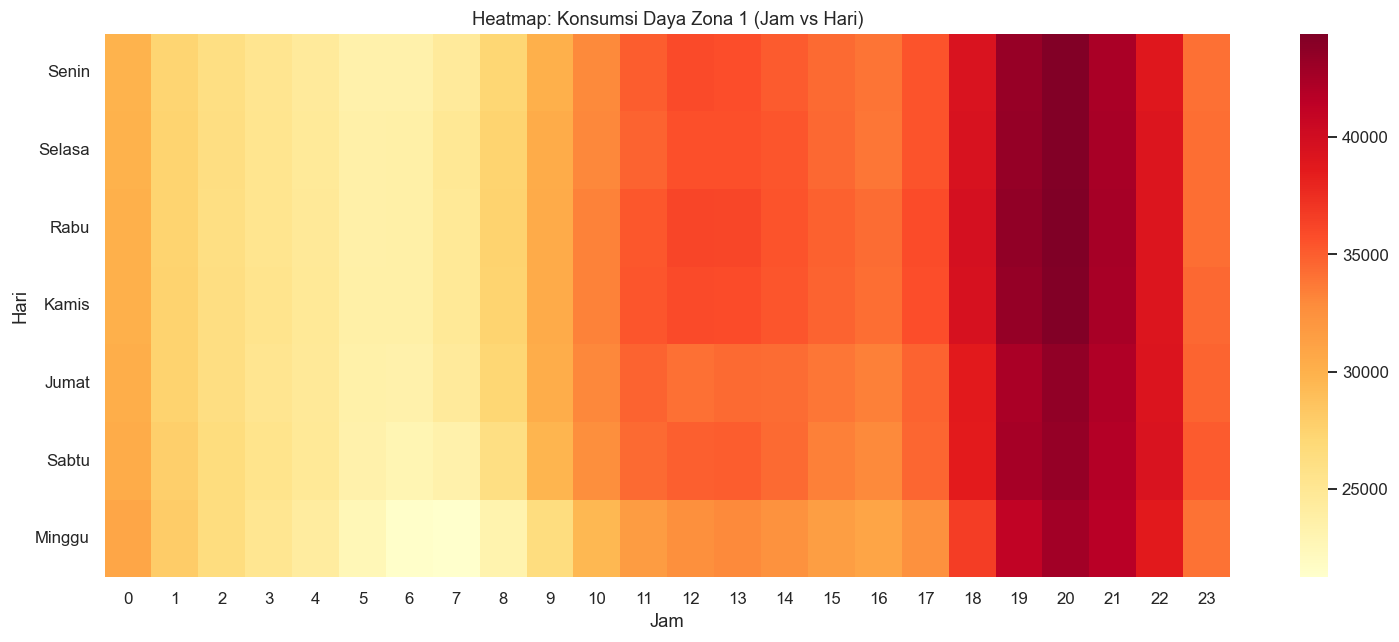

In [9]:
day_names = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
pivot = df.pivot_table(values='PowerConsumption_Zone1', index='Weekday', columns='Hour', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax)
ax.set_title('Heatmap: Konsumsi Daya Zona 1 (Jam vs Hari)')
ax.set_yticklabels(day_names, rotation=0)
ax.set_xlabel('Jam')
ax.set_ylabel('Hari')
plt.tight_layout()
plt.savefig('../data/eda_08_heatmap_jam_hari.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 11. Kesimpulan

**Insight Utama:**
- Konsumsi daya tertinggi di jam 10-14, terendah di jam 0-5
- Weekday memiliki konsumsi lebih tinggi dari Weekend
- Suhu tinggi meningkatkan konsumsi daya (pendingin ruangan)
- Zona 1 memiliki konsumsi daya tertinggi
- Terdapat pola musiman yang jelas

**Next: EXP-003 Preprocessing**